## 教程三：VarQITE 与 VQE 在同一分子基态求解上的对比研究

本教程选取 NH₃（氨）分子作为测试体系，在同一活性空间下分别运行 VarQITE 和 VQE 两种变分量子算法，并比较它们的收敛行为。我们将深入剖析二者的算法本质差异，阐释为何两种截然不同的原理最终都能获得基态能量，同时通过实际代码演示如何在统一框架下切换求解器。

### 1. 算法原理对比：虚时间演化 vs. 经典优化
虽然 VarQITE 和 VQE 都属于 变分量子算法 —— 即 **使用参数化量子电路 $|\psi(\theta)\rangle $作为试探态**，但它们在参数更新的驱动原理上有着根本区别。

#### 1.1 VQE：能量最小化的直接优化
回顾教程二，VQE 将基态求解视为一个标准的连续优化问题：
$$ \boldsymbol{\theta}^{*}=\arg\min_{\boldsymbol{\theta}}E(\boldsymbol{\theta}),\quad E(\boldsymbol{\theta})=\langle\psi(\boldsymbol{\theta})|H|\psi(\boldsymbol{\theta})\rangle \quad(1)$$
其核心是在参数空间中沿着能量下降的方向移动，典型更新规则为梯度下降：
$$ \boldsymbol{\theta}_{t+1}=\boldsymbol{\theta}_t-\eta\nabla E(\boldsymbol{\theta}_t) \quad(2)$$
梯度 $∇E$ 可通过参数平移法则或自动微分获得。这里的关键是：优化方向完全由当前点的局部能量景观决定，与系统的动力学演化无关。这种优化过程可能因贫瘠高原、局部极小等问题而停滞，但也受益于成熟的经典优化器（如 Adam）而能在许多问题上高效收敛。

#### 1.2 VarQITE：模拟虚时间演化
VarQITE 的灵感则来自真正的量子动力学。虚时间 Schrödinger 方程:
$$\frac{\partial}{\partial\tau}|\psi(\tau)\rangle=-\left(H-E(\tau)\right)|\psi(\tau)\rangle \quad(3)$$
描述了一个非幺正演化：任意初态在 $τ→∞$ 时都将按指数衰减的成分差异最终投影到基态。若我们在 ansatz 流形上模拟这一过程，参数的变化速度 **$\dot{\theta}$** 由 **McLachlan 变分原理** 决定：
$$ \sum_jF_{ij}\dot{\theta}_j=-C_i \quad(4)$$
其中 $F_{ij}=\Re\left(\langle\partial_i\psi|\partial_j\psi\rangle-\langle\partial_i\psi|\psi\rangle\langle\psi|\partial_j\psi\rangle\right)$ 是量子费舍尔信息矩阵（QFIM），$C_i=\partial E/\partial\theta_i$ 是能量梯度。  
每一步 VarQITE 并非直接追求能量极小，而是 **忠实地近似虚时间演化轨迹**。当 $Δτ$ 足够小时，参数更新:
$$ \boldsymbol{\theta}(\tau+\Delta\tau)\approx\boldsymbol{\theta}(\tau)+\dot{\boldsymbol{\theta}}\Delta\tau \quad(5)$$
自然保证了能量的单调下降，并且整体轨迹具有“冷却”特性：高频激发态成分衰减更快，从而自动引导系统流向基态。VarQITE 不需要经典优化器，其迭代方向由 QFIM 和梯度联合确定，更接近物理本质。

#### 1.3 对比要点表


在 NH₃ 分子的同一活性空间设置下，我们将同时采用这两种算法，从实践中观察它们各自的特点。

### 2. NH₃ 分子结构与活性空间
#### 2.1 几何构型

氨分子的几何结构呈三角锥形，氮原子位于锥顶，三个氢原子在底面。我们采用均衡构型：

In [11]:
nh3_geometry = [
    [0.0, 0.0, 0.1173],               # N
    [0.0, 0.9397, -0.2641],           # H1
    [0.8138, -0.4699, -0.2641],       # H2
    [-0.8138, -0.4699, -0.2641]       # H3
]

#### 2.2 活性空间与哈密顿量

使用 STO-3G 基组计算分子积分后，若进行全轨道模拟，氮原子有 5 个空间轨道，3 个 H 各有 1 个，共 8 个空间轨道 → 16 个自旋轨道 → 需要 16 个量子比特。为在示例中控制资源，我们采用 2 个活性电子、2 个活性轨道 的激进近似，将问题压缩到 4 个量子比特。  
虽然活性空间缩小了，但哈密顿量系数仍反映原始分子的电子相互作用信息。

In [12]:
import os
import torch
import matplotlib.pyplot as plt
from backends.Tensorcircuit import TensorCircuitBackend
from ansatz.HEA import HEAAnsatz
from solvers.vqe import VQESolver
from chemistry.hamiltonian import Hamiltonian

h_obj_nh3 = Hamiltonian(
    symbols=["N", "H", "H", "H"],
    geometry=nh3_geometry,
    charge=0,
    multiplicity=1
)

h_list_nh3, n_q_nh3, n_e_nh3 = h_obj_nh3.get_processed_hamiltonian(
    n_active_electrons=2,
    n_active_orbitals=2
)
print(f"NH₃ 任务: Qubits={n_q_nh3}, Electrons={n_e_nh3}")

>>> [Hamiltonian] 正在调用 Psi4 计算分子积分...
>>> [Hamiltonian] 设置活性空间: 2e, 2orb
>>> [Hamiltonian] 原始算符项数: 27
NH₃ 任务: Qubits=4, Electrons=2


### 3. Ansatz 结构与电路图
本例统一采用 HEA（深度=3）作为 ansatz，以保证与先前示例的一致性。以下输出 ansatz 的电路图，用于直观展示门结构：

In [13]:
from backends.core import QuantumCircuit

n_qubits = 4
depth = 3
params_demo = [0.1 * (i+1) for i in range(n_qubits * (depth + 1))]  # 8个浮点参数

qc = QuantumCircuit(n_qubits, name="HEA_NH3_demo")
idx = 0
for d in range(depth):
    for i in range(n_qubits):
        qc.ry(i, params_demo[idx]); idx += 1
    for i in range(n_qubits - 1):
        qc.cx(i, i + 1)
for i in range(n_qubits):
    qc.ry(i, params_demo[idx]); idx += 1

print("[Visual] HEA (depth=1) for NH₃:")
print(qc.draw(output='text', fold=-1))

[Visual] HEA (depth=1) for NH₃:
     ┌─────────┐     ┌─────────┐                      ┌─────────┐                    ┌─────────┐                      
q_0: ┤ Ry(0.1) ├──■──┤ Ry(0.5) ├────────────────■─────┤ Ry(0.9) ├──────────────■─────┤ Ry(1.3) ├──────────────────────
     ├─────────┤┌─┴─┐└─────────┘┌─────────┐   ┌─┴─┐   └─────────┘┌───────┐   ┌─┴─┐   └─────────┘┌─────────┐           
q_1: ┤ Ry(0.2) ├┤ X ├─────■─────┤ Ry(0.6) ├───┤ X ├────────■─────┤ Ry(1) ├───┤ X ├────────■─────┤ Ry(1.4) ├───────────
     ├─────────┤└───┘   ┌─┴─┐   └─────────┘┌──┴───┴──┐   ┌─┴─┐   └───────┘┌──┴───┴──┐   ┌─┴─┐   └─────────┘┌─────────┐
q_2: ┤ Ry(0.3) ├────────┤ X ├────────■─────┤ Ry(0.7) ├───┤ X ├───────■────┤ Ry(1.1) ├───┤ X ├────────■─────┤ Ry(1.5) ├
     ├─────────┤        └───┘      ┌─┴─┐   ├─────────┤   └───┘     ┌─┴─┐  ├─────────┤   └───┘      ┌─┴─┐   ├─────────┤
q_3: ┤ Ry(0.4) ├───────────────────┤ X ├───┤ Ry(0.8) ├─────────────┤ X ├──┤ Ry(1.2) ├──────────────┤ X ├───┤ Ry(1.6) ├
     └─────────┘

### 4. 运行 VQE 和 VarQITE 并比较

我们分别用两种算法对 NH₃ 进行求解，记录每一步的能量历史。

**设置环境变量**：避免 OpenMP 线程竞争

In [14]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"
os.environ["MKL_THREADING_LAYER"] = "sequential"

**VQE 部分**：

In [18]:
from ansatz.HEA import HEAAnsatz
from solvers.vqe import VQESolver
from backends.Tensorcircuit import TensorCircuitBackend

backend = TensorCircuitBackend()
ansatz_nh3 = HEAAnsatz(n_qubits=n_q_nh3, depth=3)
init_params_nh3 = torch.randn(ansatz_nh3.num_parameters, dtype=torch.float32) * 0.2

vqe_solver = VQESolver(backend)
_, _, vqe_hist = vqe_solver.solve(
    ansatz_nh3, init_params_nh3, h_list_nh3,
    steps=200, lr=0.2
)
print(f"VQE 最终能量: {vqe_hist[-1]:.6f} Hartree")

--- VQE Start (Steps=200) ---
VQE Step 0: Energy = -54.041209
VQE Step 20: Energy = -55.382260
VQE Step 40: Energy = -55.443383
VQE Step 60: Energy = -55.453248
VQE Step 80: Energy = -55.454099
VQE Step 100: Energy = -55.454234
VQE Step 120: Energy = -55.454258
VQE Step 140: Energy = -55.454266
VQE Step 160: Energy = -55.454273
VQE Step 180: Energy = -55.454281
VQE Final Energy: -55.454291
VQE 最终能量: -55.454291 Hartree


**VarQITE 部分**：

In [19]:
from solvers.var_qite import VarQITESolver

# 使用相同的初始参数，保证公平对比
var_solver = VarQITESolver(backend)
_, _, energy_hist_qite, _ = var_solver.solve(
    ansatz_nh3, init_params_nh3, h_list_nh3,
    total_tau=40.0, delta_tau=0.2, mode='autograd'
)
print(f"VarQITE 最终能量: {energy_hist_qite[-1]:.6f} Hartree")

--- VarQITE Start (Mode=autograd, Total Tau=40.0, dt=0.2) ---
Step 0: Energy = -54.041209 (Time: 0.1620s)
Step 10: Energy = -55.050781 (Time: 0.1530s)
Step 20: Energy = -55.375673 (Time: 0.1490s)
Step 30: Energy = -55.437365 (Time: 0.1451s)
Step 40: Energy = -55.451684 (Time: 0.1671s)
Step 50: Energy = -55.454413 (Time: 0.1451s)
Step 60: Energy = -55.454984 (Time: 0.1660s)
Step 70: Energy = -55.455108 (Time: 0.1540s)
Step 80: Energy = -55.455136 (Time: 0.1490s)
Step 90: Energy = -55.455143 (Time: 0.1420s)
Step 100: Energy = -55.455144 (Time: 0.1460s)
Step 110: Energy = -55.455145 (Time: 0.1470s)
Step 120: Energy = -55.455145 (Time: 0.1471s)
Step 130: Energy = -55.455145 (Time: 0.1470s)
Step 140: Energy = -55.455145 (Time: 0.1560s)
Step 150: Energy = -55.455145 (Time: 0.1500s)
Step 160: Energy = -55.455145 (Time: 0.1490s)
Step 170: Energy = -55.455145 (Time: 0.1480s)
Step 180: Energy = -55.455145 (Time: 0.1521s)
Step 190: Energy = -55.455145 (Time: 0.1489s)
Step 199: Energy = -55.455145

VQE 使用了 **lr=0.2** 和 200 步优化；VarQITE 的虚时间步长 **delta_tau=0.2**，总虚时间 40，等价于 200 步。这样在步数上对齐，便于直接对比收敛曲线。

### 5. 能量收敛可视化
在同一坐标轴上绘制两条曲线：

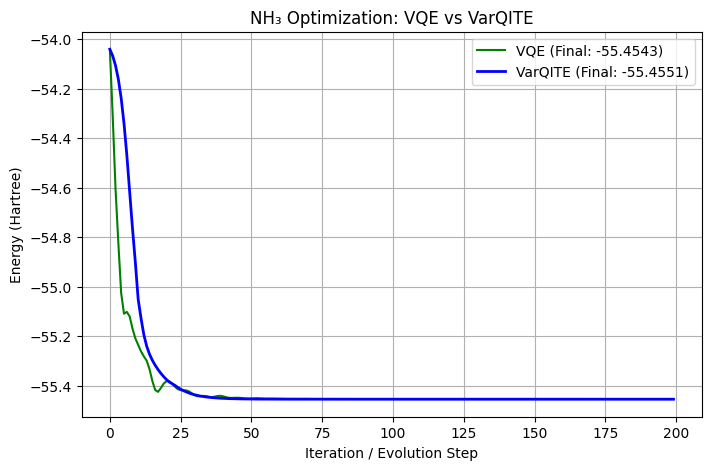

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(vqe_hist, label=f'VQE (Final: {vqe_hist[-1]:.4f})', color='g')
plt.plot(energy_hist_qite, label=f'VarQITE (Final: {energy_hist_qite[-1]:.4f})', color='b', linewidth=2)
plt.title("NH₃ Optimization: VQE vs VarQITE")
plt.xlabel("Iteration / Evolution Step")
plt.ylabel("Energy (Hartree)")
plt.legend()
plt.grid(True)
plt.show()

### 6. 结果分析与讨论
从收敛曲线可以观察到几个值得注意的现象：  

**最终精度**：在足够多步数后，两种算法的终态能量非常接近，均能稳定在某个低能值，表明在该活性空间和 ansatz 表达范围内，它们都找到了几乎相同的最优参数点。  
**稳定性**：VarQITE 的能量曲线通常呈现递降且无明显波动，因为它不是基于梯度优化的随机方向，而是由确定的线性系统驱动。VQE 有时会出现小幅反弹，取决于 Adam 的瞬时梯度。  
**硬件代价**：尽管本例中两者都用自动微分计算所需量，但在真实量子设备上，VQE 每步只需 $O(m)$ 次测量来获取梯度，而 VarQITE 需要 $O(m^2)$ 次测量构造 QFIM。后续教程中我们将介绍旨在缓解此问题的 RQITE 算法。

这些差异提醒我们：在选择算法时，应综合考虑问题规模、可用量子资源以及 ansatz 的设计。VarQITE 更贴近物理直觉且通常保证单调收敛；VQE 则受益于成熟的经典优化器工具箱，便于灵活调整。

### 7. 小结
本教程以 NH₃ 分子为载体，首次在同一数值实验背景下对比了 VarQITE 与 VQE。主要知识点包括：  

**算法原理差异**：VQE 直接最小化能量期望值，VarQITE 通过模拟虚时间演化自然“冷却”到基态。
**二者共同点**：都依赖参数化量子电路和能量期望值的测量，最终都可获得高精度能量。  
**实际表现**：在 4 量子比特活性空间中，两种方法均成功收敛至 NH₃ 的近似基态能量，且 VarQITE 展现出更平滑的下降路径。

在后续教程中，我们将引入随机化策略（RQITE）算法来解决 VarQITE 高测量开销问题，以及子空间搜索（SSQITE）算法来解决激发态的同时求解。这些改进算法进一步拓展了量子虚时间演化范式的应用边界。